2025-11-27 01:26:54,399 - INFO - Loading data from ../data/features/features_complete.csv
2025-11-27 01:26:54,518 - INFO - Loaded 26678 rows and 35 columns
2025-11-27 01:26:54,529 - INFO - Train set: 21342 samples
2025-11-27 01:26:54,529 - INFO - Test set: 5336 samples
2025-11-27 01:26:54,529 - INFO - Training Linear Regression...
2025-11-27 01:26:54,534 - INFO - Training XGBoost (default parameters)...
2025-11-27 01:26:54,617 - INFO - Training Random Forest...



Linear Regression Model Performance (LOG SCALE):
RMSE: 1.4781
MAE:  1.1791
R²:   0.0651

Linear Regression COEFFICIENTS
 1. comments_disabled               -0.7925  ███████
 2. sentiment_subjectivity           0.5664  █████
 3. has_emoji                       -0.5174  █████
 4. ratings_disabled                -0.3756  ███
 5. sentiment_polarity              -0.1292  █
 6. contains_numbers_or_emojis      -0.1198  █
 7. uppercase_words                 -0.1021  █
 8. num_emojis                      -0.0886  
 9. published_day_of_week_num        0.0072  
10. hour_of_trending                -0.0042  
11. title_length                     0.0030  
12. category_id                      0.0013  
13. days_until_trending             -0.0005  
14. is_english                       0.0000  

XGBoost Model Performance (LOG SCALE):
RMSE: 1.3463
MAE:  1.0403
R²:   0.2244

XGBoost FEATURE IMPORTANCE
 1. num_emojis                      0.1301  █████████████
 2. comments_disabled               0.1265  ███

2025-11-27 01:26:55,360 - INFO - ✅ Random Forest trained!
2025-11-27 01:26:55,402 - INFO - Starting XGBoost hyperparameter tuning...



RANDOM FOREST PERFORMANCE
RMSE: 1.3451
MAE:  1.0424
R²:   0.2258

RANDOM FOREST FEATURE IMPORTANCE
 1. title_length                    0.1808  █████████
 2. category_id                     0.1516  ███████
 3. hour_of_trending                0.1478  ███████
 4. uppercase_words                 0.1266  ██████
 5. days_until_trending             0.1058  █████
 6. sentiment_subjectivity          0.0906  ████
 7. published_day_of_week_num       0.0751  ███
 8. sentiment_polarity              0.0517  ██
 9. contains_numbers_or_emojis      0.0250  █
10. num_emojis                      0.0161  
11. has_emoji                       0.0153  
12. comments_disabled               0.0120  
13. ratings_disabled                0.0015  
14. is_english                      0.0000  
Fitting 3 folds for each of 50 candidates, totalling 150 fits
[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0.1, max_depth=7, min_child_weight=3, n_estimators=100, subsample=1.0; total time=   0.1s
[CV] END colsample

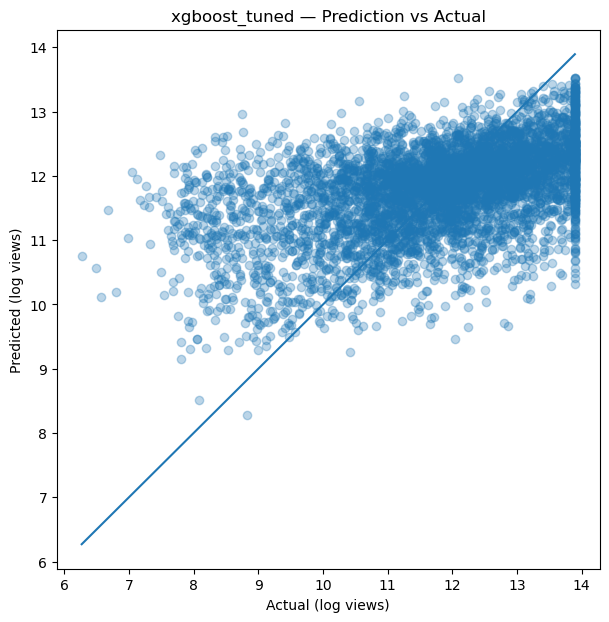

2025-11-27 01:27:05,121 - INFO - ✅ Best model (xgboost_tuned) saved to: ../models/xgboost_tuned.pkl


'../models/xgboost_tuned.pkl'

In [1]:
import sys
sys.path.append('../src')

from model_evaluator import ModelEvaluator

evaluator = ModelEvaluator('../data/features/features_complete.csv')
    
    # Run pipeline
evaluator.load_data() \
         .prepare_train_test_split() \
         .linear_regression() \
         .xgboost() \
         .randomforest() \
         .tuned_xgboost()  # This takes longest

# Get report
report = evaluator.get_models_report()
print(report)

# Save best model
evaluator.plot_predictions('xgboost_tuned')

evaluator.save_best_model('../models/xgboost_tuned.pkl')
